# Plot V from Electrode design
Jeff

Using the original design (electrodes spaced 11.130mm apart, alumina portion of electrodes 1.195mm radius)

In [1]:
import numpy as np
import re
import os
import matplotlib.pyplot as plt


## The original designs

In [2]:
def load_comsol_table(filepath):
    header_line = None
    data_lines = []

    with open(filepath, "r") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            if s.startswith("%"):
                # keep updating; the last % header line before data is the columns line
                header_line = s.lstrip("%").strip()
                continue
            data_lines.append(s)

    if not data_lines:
        raise ValueError("No numeric data found in file.")

    data = np.loadtxt(data_lines)

    # Parse column names like: "V (V)" or "es.Ex (V/m)" as single tokens
    if header_line is not None:
        colnames = re.findall(r'\S+\s*\([^)]*\)|\S+', header_line)
    else:
        colnames = [f"col{i}" for i in range(data.shape[1])]

    # Safety: if mismatch, fall back to generic names
    if len(colnames) != data.shape[1]:
        colnames = [f"col{i}" for i in range(data.shape[1])]

    return colnames, data

def plot_vs_z(filepath, ykey="V (V)", xlim=None):
    colnames, data = load_comsol_table(filepath)

    # Find Z column (in your file it's "Z", sometimes it may be "Z (mm)")
    z_candidates = ["Z", "Z (mm)", "z", "z (mm)"]
    zcol = next((c for c in z_candidates if c in colnames), None)
    if zcol is None:
        raise ValueError(f"Couldn't find a Z column. Available: {colnames}")

    if ykey not in colnames:
        raise ValueError(f"ykey='{ykey}' not found. Available: {colnames}")

    z = data[:, colnames.index(zcol)]
    y = data[:, colnames.index(ykey)]

    # Sort by Z so the line plot isn't scrambled
    order = np.argsort(z)
    z = z[order]
    y = y[order]

    plt.figure(figsize=(8, 5))
    plt.plot(z, y, label=ykey)

    # Vertical reference lines (your Z is in mm per header)
    plt.axvline(170, linestyle="dotted", color='gray', label='Short Electrode')
    plt.axvline(201, linestyle="dotted", color='black', label='Long Electrode')

    if xlim is not None:
        plt.xlim(xlim)

    plt.xlabel("Z (mm)")
    plt.ylabel(ykey)
    plt.title(f"{ykey} vs Z")
    plt.grid(True)
    plt.legend()
    plt.show()

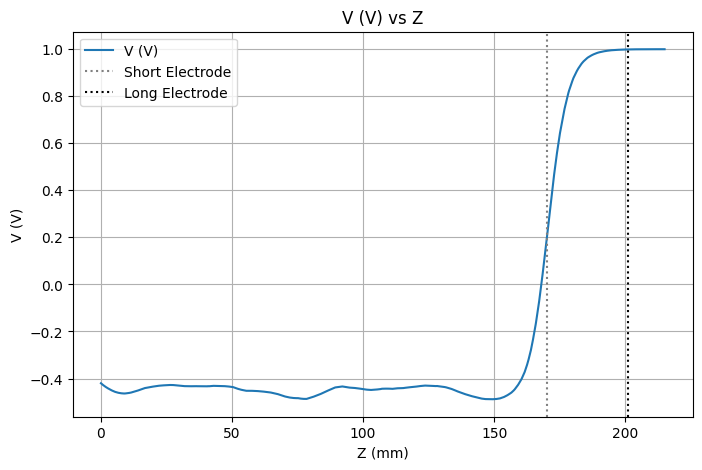

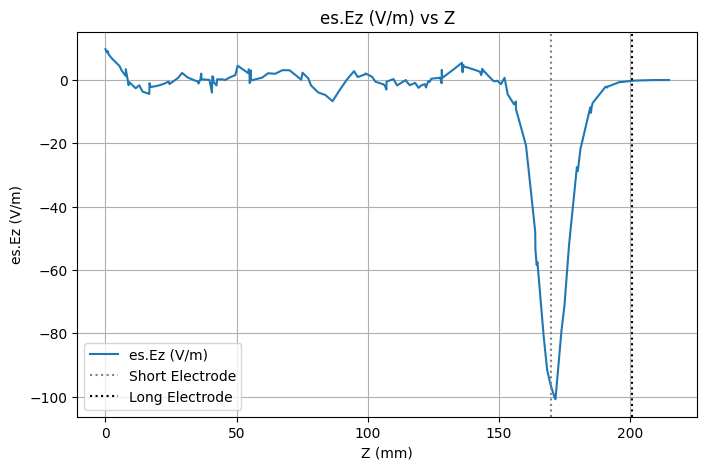

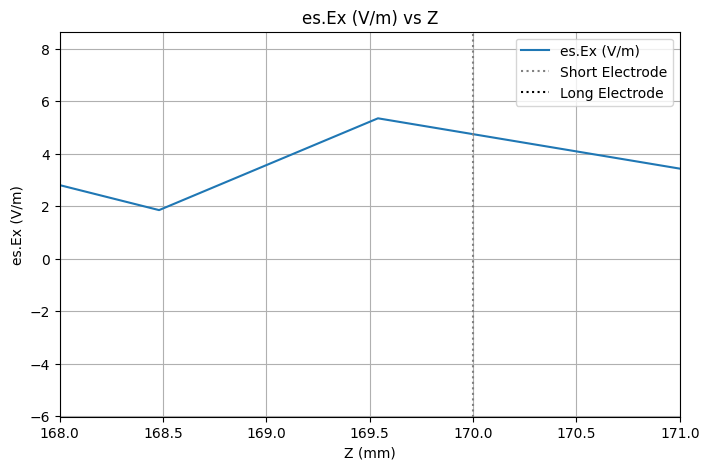

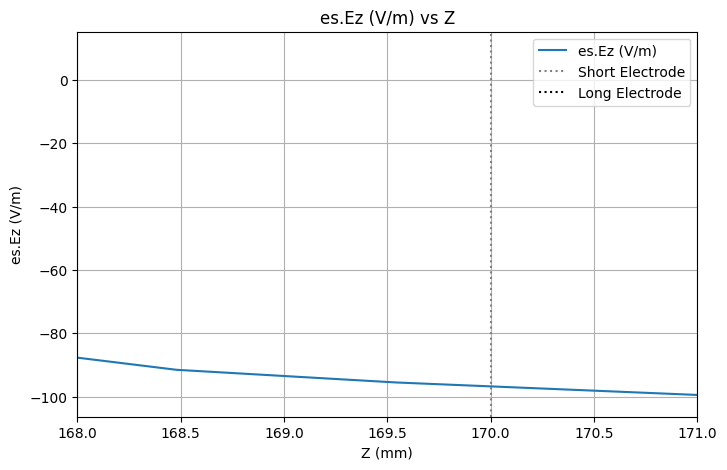

In [4]:
# ---- USER INPUT ----
folderpath = './ComsolData/OriginalCrossSections/'
filename_v1 = "ZatX0Y0_Vsneg2_rydberg.txt"   # <-- change to your file name
filepath_v1 = folderpath + filename_v1


# ---- Examples ----
plot_vs_z(filepath_v1, ykey="V (V)")          # Potential vs Z
plot_vs_z(filepath_v1, ykey="es.Ez (V/m)")    # Ez vs Z
plot_vs_z(filepath_v1, ykey="es.Ex (V/m)", xlim=(168, 171))
plot_vs_z(filepath_v1, ykey="es.Ez (V/m)", xlim=(168, 171))

## Scan Over Total Length of Experiment

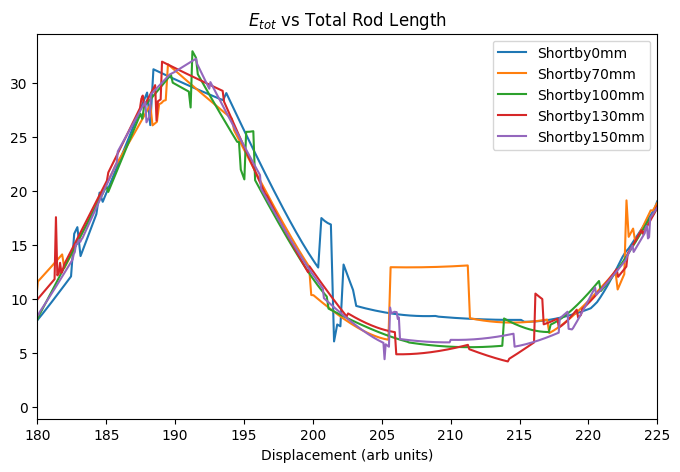

In [5]:
# ---- USER INPUT ----
folderpath = './ComsolData/TotalLength/'
filenames = ['Shortby0mm', 'Shortby70mm', 'Shortby100mm', 'Shortby130mm', 'Shortby150mm']
pi = 5
offset_list = [0,70,100,130,150]
# xlim = (168,171)
plt.figure(figsize=(8,5))
for fi in range(len(filenames)):
    f = filenames[fi]
    offset = offset_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_comsol_table(filepath)
    adjusted_x = data[:,0] + offset
    plt.plot(adjusted_x, data[:,pi], label=f)
    plt.xlabel("Displacement (arb units)")
plt.xlim((180,225))
plt.title('$E_{tot}$ vs Total Rod Length')
plt.legend()

## Scan Short Electrode Length

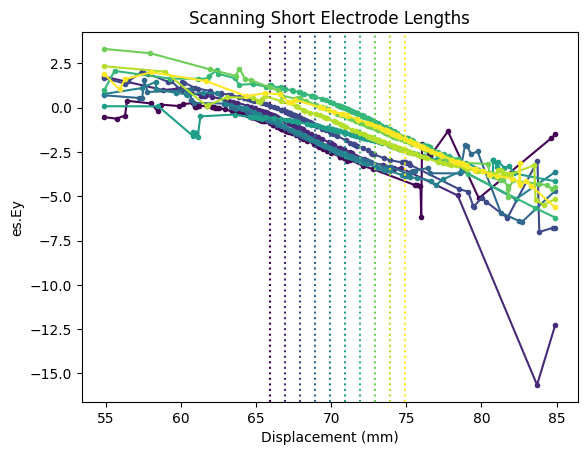

In [10]:
# ---- USER INPUT ----
folderpath = './ComsolData/ShortElectrodeLength/'
rodlengths = range(175, 185)
short_list = [f"short{i:03d}mm" for i in rodlengths]
cmap = plt.get_cmap("viridis") 
colors = cmap(np.linspace(0, 1, len(short_list)))

def load_sort_by_z_clean(filename):
    headers = None
    rows = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith("%"):
                text = line[1:].strip()
                parts = text.split()

                # Detect the actual column header row
                if "x" in parts and "y" in parts and "z" in parts:
                    headers = parts
                continue

            rows.append([float(x) for x in line.split()])

    if headers is None:
        raise ValueError("No header row with x, y, z found.")

    # Optional cleanup of header names
    cleaned_headers = []
    skip_tokens = {"(V)", "(V/m)", "@", "SL=0.175"}

    for h in headers:
        if h in skip_tokens:
            continue
        cleaned_headers.append(h)

    # For this file, the numeric columns correspond to:
    # x, y, z, V, es.Ex, es.Ey, es.Ez, es.normE
    cleaned_headers = ["x", "y", "z", "V", "es.Ex", "es.Ey", "es.Ez", "es.normE"]

    data_matrix = np.array(rows, dtype=float)

    z_index = cleaned_headers.index("z")
    data_matrix = data_matrix[np.argsort(data_matrix[:, z_index])]

    return cleaned_headers, data_matrix

pi = 5  
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    plt.plot(xdata, ydata, color=colors[fi], marker='.')
    plt.axvline(rodlengths[fi]-100-9.1, linestyle='dotted', color=colors[fi])
    plt.ylabel(cnames[pi])
    plt.xlabel("Displacement (mm)")
    plt.title("Scanning Short Electrode Lengths")

In [7]:
# Differences
pi = 6  
diffs = []
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    peak_i  = np.argmin(data[:,pi])
    peak_x = xdata[peak_i]
    diff_x = (rodlengths[fi]-100-9.1)-peak_x
    diffs.append(diff_x)

print(f"Differences between peaks + end of short electrodes {np.round(diffs,2)}")

Differences between peaks + end of short electrodes [-0.5  -0.83 -0.85 -0.72 -0.55 -0.68 -0.52 -0.5  -0.68 -0.54]


Differences between peaks + end of short electrodes []


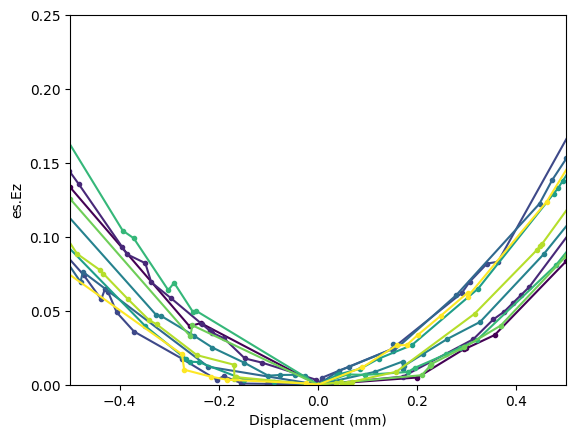

In [8]:
#Minima
pi = 6  
diffs = []
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    peak_i  = np.argmin(data[:,pi])
    peakval = np.min(data[:,pi])
    x_peakdata = xdata[peak_i-20:peak_i+20] - xdata[peak_i]
    y_peakdata = ydata[peak_i-20:peak_i+20]
    y_peakdata_norm = ydata[peak_i-20:peak_i+20] - peakval
    plt.plot(x_peakdata, y_peakdata_norm, color=colors[fi], marker='.')
    plt.xlim((-0.5,0.5))
    plt.ylim((0,0.25))
    plt.ylabel(cnames[pi])
    plt.xlabel("Displacement (mm)")
print(f"Differences between peaks + end of short electrodes {np.round(diffs,2)}")

## Fine Scan of Short Electrode Lengths w/ Final Spacing

Text(0.5, 1.0, 'Scan over Short Electrode Lengths')

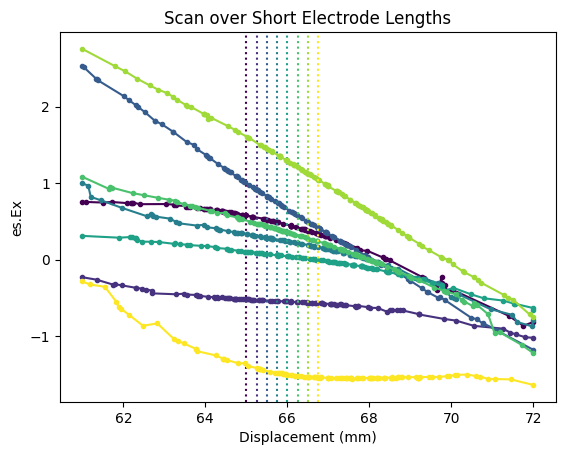

In [12]:
# ---- USER INPUT ----
folderpath = './ComsolData/FinalShortElectrodeLength/'
rodlengths = np.arange(16500, 16700, 25)
short_list = [f"short{int(i)}mm" for i in rodlengths]
cmap = plt.get_cmap("viridis") 
colors = cmap(np.linspace(0, 1, len(short_list)))

pi = 4  
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    plt.plot(xdata, ydata, color=colors[fi], marker='.')
    plt.ylabel(cnames[pi])
    plt.axvline((rodlengths[fi]/100)-100, linestyle='dotted', color=colors[fi])
    plt.xlabel("Displacement (mm)")

plt.title("Scan over Short Electrode Lengths")

In [23]:
# Differences
pi = 6  
diffs = []
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    peak_i  = np.argmin(data[:,pi])
    peak_x = xdata[peak_i]
    diff_x = ((rodlengths[fi]/100)-100)-peak_x
    diffs.append(diff_x)

print(f"Differences between peaks + end of short electrodes {np.round(diffs,2)}")

Differences between peaks + end of short electrodes [-0.53 -0.81 -0.87 -0.77 -0.7  -0.7  -0.49 -0.75]


## Scan Width of Electrodes

Text(0.5, 1.0, 'Scan Over Width of Electrode Spacing')

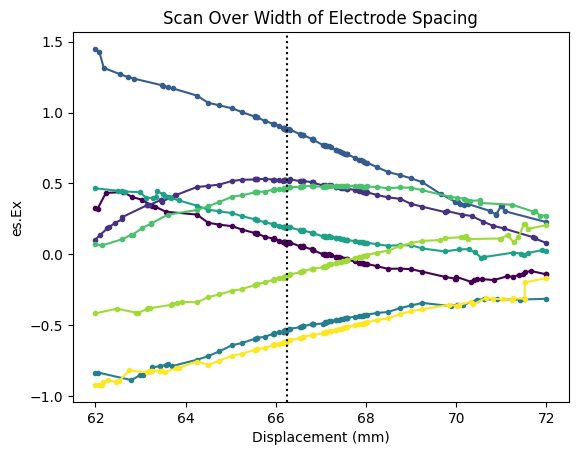

In [14]:
# ---- USER INPUT ----
folderpath = './ComsolData/FinalWidth/'
rodlengths = np.arange(140, 156, 2)
short_list = [f"width{int(i)}" for i in rodlengths]
cmap = plt.get_cmap("viridis") 
colors = cmap(np.linspace(0, 1, len(short_list)))

pi = 4  
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    plt.plot(xdata, ydata, color=colors[fi], marker='.')
    plt.ylabel(cnames[pi])
    plt.xlabel("Displacement (mm)")

plt.axvline(66.25, linestyle='dotted', color='black')
plt.title("Scan Over Width of Electrode Spacing")

In [32]:
# Differences
pi = 6  
diffs = []
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    peak_i  = np.argmin(data[:,pi])
    peak_x = xdata[peak_i]
    diff_x = (166.25-100)-peak_x
    diffs.append(diff_x)

print(f"Differences between peaks + end of short electrodes {np.round(diffs,2)}")

Differences between peaks + end of short electrodes [-0.58 -0.56 -0.58 -0.34 -0.58 -0.58 -0.84 -0.84]


## Scan Tip Tilt Parallel to Axial Plane

Text(0.5, 1.0, 'Scan Over Electrode Tip/Tilt Parallel to Ax (-1 deg to 1 deg)')

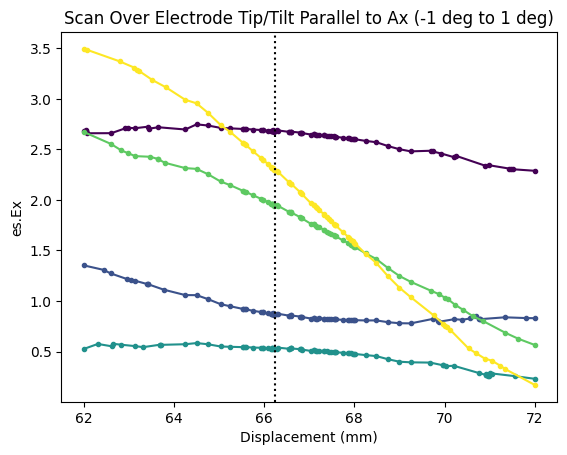

In [23]:
# ---- USER INPUT ----
folderpath = './ComsolData/TipTiltParalleltoAxialPlane/'
short_list = ["neg1deg", "neg05deg", "0deg", "05deg", "1deg"]
cmap = plt.get_cmap("viridis") 
colors = cmap(np.linspace(0, 1, len(short_list)))

pi = 4
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    plt.plot(xdata, ydata, color=colors[fi], marker='.')
    plt.ylabel(cnames[pi])
    plt.xlabel("Displacement (mm)")

plt.axvline(66.25, linestyle='dotted', color='black')
plt.title("Scan Over Electrode Tip/Tilt Parallel to Ax (-1 deg to 1 deg)")

## Scan Tip Tilt into Axial Plane

Text(0.5, 1.0, 'Scan Over Width of Electrode Tip/Tilt (-1 deg to 1 deg)')

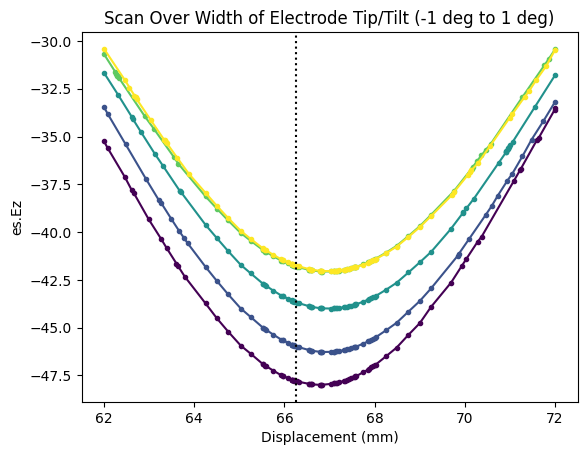

In [26]:
# ---- USER INPUT ----
folderpath = './ComsolData/TipTiltIntoAxial/'
short_list = ["neg1deg", "neg05deg", "0deg", "05deg", "1deg"]
cmap = plt.get_cmap("viridis") 
colors = cmap(np.linspace(0, 1, len(short_list)))

pi = 6
for fi in range(len(short_list)):
    f = short_list[fi]
    filepath = folderpath + f + '.txt'
    cnames, data = load_sort_by_z_clean(folderpath+short_list[fi]+".txt")
    xdata = data[:,2]
    ydata = data[:,pi]
    plt.plot(xdata, ydata, color=colors[fi], marker='.')
    plt.ylabel(cnames[pi])
    plt.xlabel("Displacement (mm)")

plt.axvline(66.25, linestyle='dotted', color='black')
plt.title("Scan Over Width of Electrode Tip/Tilt (-1 deg to 1 deg)")